Importing libraries

In [12]:
import os
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from datetime import datetime
import numpy as np

Definindo variáveis p/ funções:
- file_id: google drive file id
- output: caminho de saída do arquivo baixado

In [13]:
file_id = '1Ki8nvHJx91LM_vTZ7motgNhCF9fjyfGg'
output = 'data/raw/dados_projeto.csv'

Função para baixar o arquivo CSV do Google Drive

In [14]:
def download_csv_from_drive(file_id: str, output_path: str) -> None:
    """
    Baixa um arquivo CSV do Google Drive usando gdown.

    Args:
        file_id (str): ID do arquivo no Google Drive.
        output_path (str): Caminho onde salvar o arquivo baixado.
    """
    # Cria a pasta se não existir
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Sempre baixa o arquivo, sobrescrevendo se necessário
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output_path, quiet=False)
    print(f"Arquivo baixado para {output_path} com sucesso.")

Função pra ler e tratar o arquivo base

In [15]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Carrega um arquivo CSV e realiza limpeza básica dos dados.

    Args:
        filepath (str): Caminho para o arquivo CSV.

    Returns:
        pd.DataFrame: DataFrame limpo.
    """
    df = pd.read_csv(filepath)
    print("resumo dos dados")
    print(df.describe())

    # Exemplo: remover nulos, converter tipos de dados, etc.
    df['generic_model_name'] = df['model_name'].str.split().str[0].str.split('-').str[0].str.upper() #extrai a parte genérica do nome do modelo (ex: "gpt-3.5-turbo" -> "gpt")
    df['clean_model_name'] = df['model_name'].str.split('(').str[0]
    df['reasoning level'] = df['generic_model_name'].str.extract(r'\((.*?)\)', expand=False).fillna('Unknown')
    #transformar a coluna de ano de lançamento em inteiro, forçando erros a se tornarem NaN
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')
    # Converter tipos de dados para os mais apropriados automaticamente
    df = df.convert_dtypes()
    # Remover linhas com valores nulos em colunas críticas
    df = df.dropna(how='all') #incluir subset=['coluna1', 'coluna2'] para especificar colunas que não podem ser nulas
    return df

In [53]:
def standardize_fields(df: pd.DataFrame) -> pd.DataFrame:
    """
    Padroniza campos do DataFrame para uso em plotagem ou outras funções.

    Args:
        df (pd.DataFrame): DataFrame a ser padronizado.

    Returns:
        pd.DataFrame: DataFrame com campos padronizados.
    """
    # Exemplo: converter tipos, renomear colunas, etc.
    # Ajuste conforme os dados específicos
    df = df.copy()
    # Converter colunas numéricas
    numeric_cols = df.select_dtypes(include=['object']).columns
    for col in numeric_cols:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except:
            pass
    # Padronizar nomes de colunas para lowercase
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

In [23]:
def save_dataframe(df: pd.DataFrame, output_path: str) -> None:
    """
    Salva um DataFrame em um arquivo CSV.

    Args:
        df (pd.DataFrame): DataFrame a ser salvo.
        output_path (str): Caminho onde salvar o arquivo CSV.
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    try:
        df.to_csv(output_path, index=False)
        print(f"DataFrame salvo em {output_path} com sucesso.")
    except Exception as e:
        print(f"Erro ao salvar o DataFrame em {output_path}: {e}")


Aplicando as funções em ordem (conforme o orquestrador na main.py estaria chamando)

In [18]:
download_csv_from_drive(file_id, output)

Downloading...
From: https://drive.google.com/uc?id=1Ki8nvHJx91LM_vTZ7motgNhCF9fjyfGg
To: /content/data/raw/dados_projeto.csv
100%|██████████| 99.9k/99.9k [00:00<00:00, 4.14MB/s]

Arquivo baixado para data/raw/dados_projeto.csv com sucesso.


In [24]:
df = load_and_clean_data(output)

resumo dos dados
       aa_intelligence_index  aa_coding_index  aa_math_index  \
count             446.000000       356.000000     268.000000   
mean               21.241256        19.507022      50.358209   
std                11.969957        12.756695      30.683282   
min                 4.700000         0.000000       0.000000   
25%                12.000000        10.000000      23.350000   
50%                17.950000        16.650000      52.800000   
75%                28.475000        28.750000      79.475000   
max                57.200000        57.300000      99.000000   

       composite_benchmark    mmlu_pro  gpqa_diamond  humanitys_last_exam  \
count           433.000000  344.000000    424.000000           420.000000   
mean             43.885358    0.695875      0.597344             0.089479   
std              15.960437    0.167493      0.193779             0.074591   
min               4.100000    0.055000      0.098000             0.012000   
25%              33.6

In [25]:
df = standardize_fields(df)

In [26]:
save_dataframe(df, 'data/processed/dados_projeto_limpos.csv')

DataFrame salvo em data/processed/dados_projeto_limpos.csv com sucesso.


## **Definição de temas padrão**

In [27]:
def apply_custom_style():
    """Configura o look-and-feel global do projeto."""
    px.defaults.template = "seaborn"
    #px.defaults.color_continuous_scale = "Viridis"
    pio.templates[px.defaults.template]['layout']['hovermode'] = 'x unified'

    pio.templates["seaborn"].update({
        "layout": {
            "title_x": 0.5,            # Títulos centralizados
            "hovermode": "x unified",  # Hover profissional
            "xaxis": dict(automargin=True),
            "yaxis": dict(automargin=True)
        }
    })

In [28]:
apply_custom_style()

##**Plotagem de gráficos**

####**Gráficos de Linhas**

In [29]:
def plot_performance_line_interactive(data, x_col, y_col, title=None, group_col=None, n=None):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    # Se n for fornecido, filtra os top n antes de plotar
    if n and group_col:
        # 1. Identifica os grupos baseado na performance total/média
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        # 2. Filtra o dataframe original mantendo a granularidade
        data = data[data[group_col].isin(top_groups)]
        # 3. Agrupa POR DATA e GRUPO para garantir que a linha seja contínua
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()

    elif n:
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
        top_n = data.sort_values(by=y_col, ascending=False).head(n)#
        data = top_n[[x_col, y_col]]#
    else:
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
        n = data[y_col].nunique()#
        top_n = data.sort_values(by=y_col, ascending=False).head(n)#

    fig = px.line(data, x=x_col, y=y_col, color=group_col, markers=True, title=title)
    fig.update_xaxes(tickformat="d") # Formata o eixo x para mostrar apenas os anos como inteiros
    fig.update_layout(
        #xaxis=dict(automargin=True),
        xaxis_title=x_col.title().replace('_', ' '),#
        xaxis_rangeslider_visible=True, #Mostra Slider de seleção horizontal
        xaxis_anchor="y",# Trava o eixo X ao eixo Y

        yaxis_title=y_col.title().replace('_', ' '),#
        #yaxis_autorange=True,#
        yaxis_domain=[0.15, 1],#
        yaxis_anchor="x",     # Trava o eixo Y ao eixo X
        yaxis_side="left",    # Garante que ele fique fixo à esquerda

        legend_title=group_col.title().replace('_', ' '),#
    )

    filename = f"plot_line_{title}_{ts}"
    os.makedirs('data/figures', exist_ok=True)

    fig.write_html(f"data/figures/{filename}.html")


    return fig

#### **Geração dos arquivos**

In [30]:
plot_performance_line_interactive(df, 'release_year', 'intelligence_per_dollar', title='Intelligence per Dollar on models', group_col='generic_model_name',n=20)

In [31]:
plot_performance_line_interactive(df, 'release_year', 'speed_per_dollar', title='Speed per Dollar on models', group_col='generic_model_name',n=20)

In [32]:
plot_performance_line_interactive(df, 'release_year', 'intelligence_per_dollar', title='Intelligence per Dollar Open X Closed', group_col='is_open_source',n=20)

In [33]:
plot_performance_line_interactive(df, 'release_year', 'blended_cost_usd_per_1m', title='Blended Cost per Dollar Open X Closed', group_col='provider',n=20)

In [34]:
plot_performance_line_interactive(df, 'release_year', 'blended_cost_usd_per_1m', title='Blended Cost per Dollar Open X Closed', group_col='generic_model_name',n=20)

#### **Gráficos de barra (Barras Horizontais e Verticais)**

In [35]:
def plot_performance_barh_interactive(data, x_col, y_col, title=None, group_col=None, n=None, calculate='sum'):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    data = data.sort_values(by=y_col, ascending=True)
    if calculate not in ('mean', 'sum'):
        raise ValueError("calculate deve ser 'mean' ou 'sum'")

    # 1. Agrega todo o conjunto de dados primeiro para não perder precisão no cálculo
    if group_col:
        # Se tem grupo, agrupamos por X e pelo Grupo
        data_agg = data.groupby([x_col, group_col], dropna=False)[y_col].agg(calculate).reset_index()
    else:
        # Agrupamento simples por X
        data_agg = data.groupby(x_col, dropna=False)[y_col].agg(calculate).reset_index()

    print(data_agg.describe())
    # 2. Determina quem são os Top N baseados no valor agregado final
    if n:
        # Agrupamos novamente por X para garantir que estamos pegando os N melhores 'modelos'
        # (independente de como os grupos internos se dividem)
        top_indices = data_agg.groupby(x_col)[y_col].sum().nlargest(n).index
        data_agg = data_agg[data_agg[x_col].isin(top_indices)]

    # 3. Ordenação para o gráfico (Garante que o maior fique no topo no gráfico de barras)
    data_agg = data_agg.sort_values(by=y_col, ascending=True)

    # 4. Criação do gráfico (se for horizontal, x e y se invertem)
    fig = px.bar(data_agg, x=y_col, y=x_col, color=group_col, title=title, orientation='h',text_auto=True)

    fig.update_layout(

        xaxis=dict(automargin=True),
        xaxis_title=y_col.title().replace('_', ' '),

        yaxis=dict(automargin=True),
        yaxis_title=x_col.title().replace('_', ' '), # Reforça a ordem visual
        yaxis_tickformat='d'

    )

    filename = f"plot_barh_{title}"
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")

    return fig

## **Plotagem dos Histogramas**

Função

In [36]:
def plot_performance_histogram_interactive(data, x_col, y_col, title=None, group_col=None, n=None):
    # 1. Filtro Top N (Precisa ser feito antes, pois o Plotly não corta o DF sozinho)
    if n:
        # Encontra os N maiores valores por categoria
        top_categories = data.groupby(x_col)[y_col].max().nlargest(n).index
        data = data[data[x_col].isin(top_categories)]

    # 2. Criação do Histograma (usando histfunc='max')
    fig = px.histogram(
        data,
        x=y_col,
        y=x_col,
        color=group_col,
        title=title,
        orientation='h',
        histfunc='max',  # Define a lógica do cálculo como o maior valor
        barmode='group', # Garante que as barras fiquem lado a lado se houver grupos
        text_auto='.2s'   # Formata o número automaticamente
    )

    # 3. Ajustes de layout e ordenação
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'}, # Ordena o eixo Y pelo valor total da barra
        xaxis_title=y_col.replace('_', ' ').title(),
        yaxis_title=x_col.replace('_', ' ').title(),
        bargap=0.2
    )

    # 4. Salvamento
    os.makedirs('data/figures', exist_ok=True)
    filename = f"hist_max_{title if title else 'plot'}_{datetime.now().strftime('%H%M%S')}.html"
    fig.write_html(f"data/figures/{filename}")

    return fig

Exibição dos gráficos

In [37]:
plot_performance_histogram_interactive(df, 'provider', 'intelligence_per_dollar', n=10)

In [38]:
plot_performance_histogram_interactive(df, 'clean_model_name', 'intelligence_per_dollar', n=10)

In [39]:
plot_performance_histogram_interactive(df, 'provider', 'speed_per_dollar', n=10)

In [40]:
plot_performance_histogram_interactive(df, 'clean_model_name', 'speed_per_dollar', n=10)

In [42]:
plot_performance_histogram_interactive(df, 'provider', 'intelligence_per_dollar', n=10)

#### **Matriz de correlação**

In [43]:
def plot_correlation_heatmap(data, cols, title=None):

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    corr = data[cols].corr()
    fig = px.imshow(
        corr,
        text_auto=True,
        aspect="auto",
        title=title,
        color_continuous_scale='RdBu',
        zmin=-1,
        zmax=1
    )
    fig.update_layout(xaxis_title="Métricas", yaxis_title="Métricas", xaxis=dict(automargin=True), yaxis=dict(automargin=True),)
    # paleta de cores do azul pro vermelho, passando por branco no meio
    fig.update_traces(colorbar_title='Correlação')
    # atualizar nomes de eixo de forma consistente
    tick_labels = [col.replace('_', ' ').title() for col in cols]
    tick_vals = list(range(len(cols)))
    fig.update_xaxes(tickvals=tick_vals, ticktext=tick_labels)
    fig.update_yaxes(tickvals=tick_vals, ticktext=tick_labels)
    fig.update_layout(hovermode='closest')

    filename = f"plot_correlation_{title}"
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")

    return fig

In [46]:
plot_correlation_heatmap(df, ['release_year', 'aa_intelligence_index', 'time_to_first_answer_s','blended_cost_usd_per_1m', 'price_performance_ratio', ], title='Correlação entre Métricas de Desempenho e Tempo')

## **Gráfico de Dispersão por Release Year**

In [54]:
def plot_scatter_interactive(data, x_col, y_col, title=None, group_col=None, n=None, filter=False):
    """Plota um gráfico de dispersão interativo com métodos customizáveis usando Plotly.
    args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x.
        y_col (str): Nome da coluna para o eixo y.
        title (str, opcional): Título do gráfico. Padrão é None.
        group_col (str, opcional): Nome da coluna para agrupar por cor. Padrão é None.
        n (int, opcional): Número de top grupos a serem plotados. Padrão é None (todos os grupos).
        filter (bool, opcional): Se True, adiciona um filtro por ano de lançamento (release_year) usando um slider. Padrão é False.
    returns:
        plotly.graph_objs._figure.Figure: Objeto da figura do gráfico de dispersão.
    """

    #ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    # Garantir que a coluna 'release_year' seja do tipo numérico para evitar problemas no filtro
    data=data.copy().dropna(subset=['release_year'])

    # Se n for fornecido, filtra os top n antes de plotar
    if group_col and n:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
    elif n:
        data = data.sort_values(by=y_col, ascending=False).head(n)

    # Para garantir que as categorias sejam ordenadas de forma consistente, criamos um dicionário de ordens de categoria baseado na média de y_col para cada grupo, ordenado de forma decrescente. Isso ajuda a manter uma ordem lógica nas legendas e cores do gráfico.
    category_orders = {}
    if group_col:
        group_order = data.groupby(group_col)[y_col].mean().sort_values(ascending=False).index.tolist()
        category_orders[group_col] = group_order
    # Agora, ao criar o gráfico de dispersão, passamos o parâmetro category_orders para garantir que as categorias sejam ordenadas de forma consistente com a média de y_col. Isso é especialmente útil para gráficos de dispersão onde a cor ou o agrupamento é baseado em categorias, garantindo que a legenda e as cores sejam apresentadas de forma lógica e fácil de interpretar.
    fig = px.scatter(
        data,
        x=x_col,
        y=y_col,
        color=group_col,
        title=title,
        category_orders=category_orders,
        labels={
            x_col: x_col.replace('_', ' ').title(),
            y_col: y_col.replace('_', ' ').title()
        },
    )

    # Configurações adicionais para melhorar a aparência do gráfico
    fig.update_traces(marker=dict(size=8, opacity=0.8))
    if group_col:
        fig.update_layout(
            legend_title=group_col.replace('_', ' ').title(),
            legend_traceorder='normal'
        )

    # Se filter for True e a coluna 'release_year' estiver presente, adiciona um slider para filtrar os dados por ano de lançamento
    if filter and 'release_year' in data.columns:
        # Ordena os anos de lançamento e cria um botão para cada ano
        years = sorted(data['release_year'].dropna().astype(int).unique())
        buttons = []

        for year in years:

            if group_col:
                x_vals = []
                y_vals = []

                for trace in fig.data: # Itera sobre cada traço (grupo) no gráfico
                    mask = (
                        (data[group_col] == trace.name) &
                        (data['release_year'].astype(int) == year)
                    )
                    # Convert pd.NA to None for JSON serialization compatibility
                    x_vals.append(data.loc[mask, x_col].replace({pd.NA: None}).tolist())
                    y_vals.append(data.loc[mask, y_col].replace({pd.NA: None}).tolist())

            else:
                mask = data['release_year'].astype(int) == year
                # Convert pd.NA to None for JSON serialization compatibility
                x_vals = [data.loc[mask, x_col].replace({pd.NA: None}).tolist()]
                y_vals = [data.loc[mask, y_col].replace({pd.NA: None}).tolist()]

            # Adição do botão para filtrar os dados por ano de lançamento
            buttons.append(dict(
                label=str(year),
                method='update',
                args=[
                    {'x': x_vals, 'y': y_vals},
                    {'title': f"{title or ''} - {year}"}
                ]
            ))

        # Adiciona um botão para mostrar todos os dados
        fig.update_layout(
            updatemenus=[dict(
                active=len(buttons) - 1,
                buttons=buttons,
                x=-0.1,
                #y=1.20,
                xanchor='right',
                yanchor='top'
            )],
            hovermode='closest'
        )

    filename = f"plot_scatter_{title}"
    os.makedirs('data/figures', exist_ok=True)

    fig.write_html(f"data/figures/{filename}.html")

    return fig

In [55]:
plot_scatter_interactive(df, 'blended_cost_usd_per_1m', 'aa_coding_index', group_col='clean_model_name', n=20, filter=True, title='Habilidade de programação vs Custo em dólar por 1M de Tokens')

#### **Gráfico de dispersão Custo X Inteligência com destaques**

In [56]:
def plot_value_for_money(data):
    try:
        # Filtrar a base: Remover linhas que estão com o Preço ou a Inteligência em branco (NaN)
        df_clean = data.dropna(subset=['blended_cost_usd_per_1m', 'composite_benchmark'])

        # ==========================================
        # FASE DE ANÁLISE E GRÁFICO (TEMA A)
        # ==========================================

        # Filtrar dados para garantir que o custo seja positivo para a escala logarítmica
        df_plotted = df_clean[df_clean['blended_cost_usd_per_1m'] > 0].copy()

        # Calcular uma métrica de custo-benefício (Inteligência / Custo)
        # Adicionar um pequeno valor ao custo para evitar divisão por zero se houver algum custo 0
        df_plotted['cost_benefit_ratio'] = df_plotted['composite_benchmark'] / (df_plotted['blended_cost_usd_per_1m'])

        # Identificar os 5 melhores modelos por custo-benefício APÓS filtrar por custo positivo
        top_5_models = df_plotted.nlargest(5, 'cost_benefit_ratio')

        # Separar as variáveis X (Custo) e Y (Inteligência) usando numpy do DataFrame filtrado
        x = df_plotted['blended_cost_usd_per_1m'].values
        y = df_plotted['composite_benchmark'].values

        # Calcular a correlação estatística básica usando numpy
        correlacao = np.corrcoef(x, y)[0, 1]
        print(f"Modelos analisados: {len(df_plotted)}")
        print(f"Correlação entre Custo e Inteligência: {correlacao:.2f}")

        # Debug: Print data ranges
        print(f"X (Custo) min: {x.min()}, X max: {x.max()}")
        print(f"Y (Inteligência) min: {y.min()}, Y max: {y.max()}")
        print(f"Top 5 X (Custo) min: {top_5_models['blended_cost_usd_per_1m'].min()}, Top 5 X max: {top_5_models['blended_cost_usd_per_1m'].max()}")
        print(f"Top 5 Y (Inteligência) min: {top_5_models['composite_benchmark'].min()}, Top 5 Y max: {top_5_models['composite_benchmark'].max()}")

        # Configurar e criar o Gráfico de Dispersão (Scatter Plot)
        fig, ax = plt.subplots(figsize=(15, 9)) # Aumentar o tamanho para acomodar os rótulos e evitar o warning
        ax.scatter(x, y, alpha=0.6, color='teal', edgecolors='black', label='Outros Modelos')

        # Plotar os 5 melhores modelos em destaque
        ax.scatter(top_5_models['blended_cost_usd_per_1m'],
                   top_5_models['composite_benchmark'],
                   color='red', s=150, edgecolors='white', zorder=5, label='Top 5 Custo-Benefício') # Tamanho maior e cor distinta

        # Adicionar rótulos aos top 5 modelos
        for i, row in top_5_models.iterrows():
            ax.text(row['blended_cost_usd_per_1m'] * 1.1, # Ajustar a posição x ligeiramente para legibilidade
                    row['composite_benchmark'],
                    row['model_name'],
                    fontsize=9, ha='left', va='center', color='darkred', weight='bold')

        # Usar escala logarítmica no Eixo X porque os preços variam drasticamente
        # (de $0.01 a mais de $100 por 1 milhão de tokens)
        ax.set_xscale('log')

        # Adicionar títulos e rótulos bem explicativos
        ax.set_title('Análise: Custo vs. Inteligência dos Modelos de IA', fontsize=16, pad=15)
        ax.set_xlabel('Custo Combinado (USD por 1 Milhão de Tokens) - Escala Logarítmica', fontsize=12)
        ax.set_ylabel('Nota de Inteligência (Composite Benchmark)', fontsize=12)

        # Adicionar linhas de grade para facilitar a visualização no trabalho
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

        # Adicionar legenda
        ax.legend()

        # Evitar que os textos fiquem cortados e salvar a imagem
        os.makedirs('data/figures', exist_ok=True)
        plt.savefig('data/figures/custo_vs_inteligencia.png', bbox_inches='tight')

    except Exception as e:
        print(e)

Modelos analisados: 295
Correlação entre Custo e Inteligência: 0.29
X (Custo) min: 0.02, X max: 35.0
Y (Inteligência) min: 4.1, Y max: 92.4
Top 5 X (Custo) min: 0.025, Top 5 X max: 0.094
Top 5 Y (Inteligência) min: 28.04, Top 5 Y max: 53.1


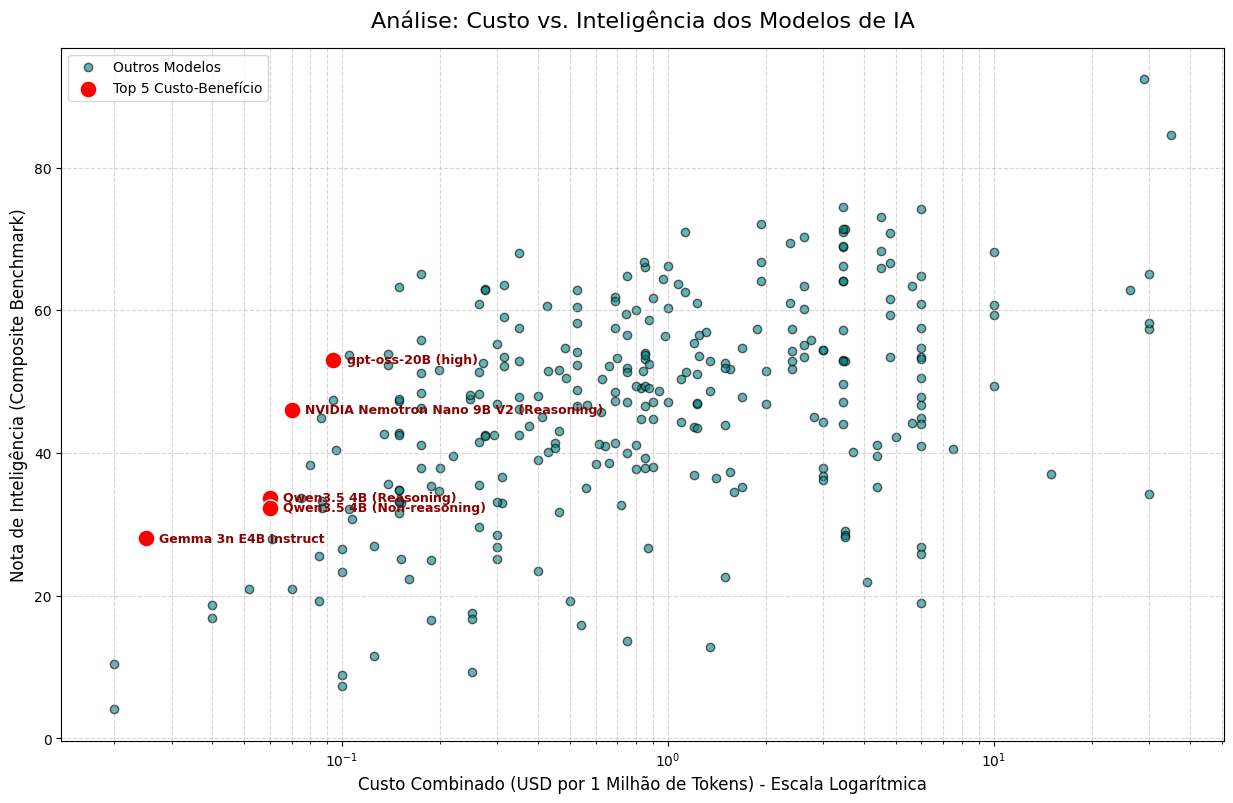

In [58]:
plot_value_for_money(df)

#### **Gráfico de Área (com ou sem slider)**

In [66]:
def plot_area_freq_interactive(data, x_col, group_col,sort_by='x',slider=True):
    #ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    x_col_clean = x_col.replace('_',' ').title()
    group_col_clean = group_col.replace('_',' ').title()
    title=f"Quantidade de modelos por {x_col_clean} separados por {group_col_clean}"
    data_counts = data.groupby([x_col, group_col]).size().reset_index(name='Count')
    match sort_by:
        case 'x':
            data_counts = data_counts.sort_values(by=x_col).fillna(0)
        case 'y':
            data_counts = data_counts.sort_values(by=['Count',x_col], ascending=True).fillna(0)
        case _:
            raise Exception("The sort_by parameter must be 'x' or 'y'.")

    max_y = data_counts.groupby(x_col)['Count'].sum().max()
    fig = px.area(data_counts,x=x_col, y='Count', color=group_col, title=title, labels={'Count': 'Total de Ocorrências ', x_col: x_col_clean, group_col : group_col_clean}, animation_frame=group_col if slider else None)

    fig.update_xaxes(tickformat='%d')
    fig.update_yaxes(range=[0,max_y])
    fig.update_traces(showlegend=False if slider else True)
    fig.update_layout(showlegend=False if slider else True)


    filename = f"plot_area_{title}"
    os.makedirs('data/figures', exist_ok=True)

    fig.write_html(f"data/figures/{filename}.html")

    return fig


Exemplo sem slider

In [67]:
plot_area_freq_interactive(df, "release_year", group_col='pricing_tier',sort_by='x', slider=False)

Exemplo com slider

In [69]:
plot_area_freq_interactive(df, "release_year", group_col='pricing_tier',sort_by='x', slider=True)

In [70]:
def plot_donut_interactive(data, measure, categories):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    data_grouped = data.groupby(categories)[measure].nunique().reset_index()
    data_group = data_grouped.sort_values(categories)
    print(data_grouped)
    measure_clean = measure.replace('_',' ').title()
    categories_clean = categories.replace('_',' ').title()
    title = f'{measure_clean} X {categories_clean}'
    fig = px.pie(data_grouped, values=measure, names=categories, title=title, hole=0.5)
    fig.update_traces(textposition='outside', textinfo='label+percent', marker=dict(line=dict(color='#fff', width=3)))

    filename = f"plot_donut_{title}"
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")


    return fig

In [71]:
 plot_donut_interactive(df,'model_name','is_open_source',)

   is_open_source  model_name
0           False         151
1            True         302


In [72]:
plot_donut_interactive(df,'blended_cost_usd_per_1m','is_open_source',)

   is_open_source  blended_cost_usd_per_1m
0           False                       42
1            True                       90


In [73]:
 plot_donut_interactive(df,'model_name','pricing_tier')

  pricing_tier  model_name
0       Budget         111
1         Free          16
2          Mid         152
3      Premium          27
4        Ultra           9
5      Unknown         138
